# Pandas Crash Course: CSV Data Analysis

Welcome to the world of data analysis! Today we'll learn how to use pandas to analyze real data from CSV files. Pandas is like a supercharged Excel - it lets you load, clean, analyze, and visualize data with just a few lines of code.

We'll analyze sales data from a fictional online store to answer business questions and create visualizations.

## Setting Up: Import Libraries and Data

In [1]:
try:
    import pandas as pd
    import matplotlib.pyplot as plt
except ImportError as e:
    !pip install pandas matplotlib
    import pandas as pd
    import matplotlib.pyplot as plt

import random
from datetime import datetime, timedelta

print("Libraries imported successfully!")
print(f"Pandas version: {pd.__version__}")

Libraries imported successfully!
Pandas version: 2.3.3


For simplicity, we've added data for you to this repository in `sales_data.csv`. We found it on [Kaggle](https://www.kaggle.com/datasets/kyanyoga/sample-sales-data) - a great resource for datasets.

## Loading Data: Your First Pandas DataFrame

In [2]:
# Load the CSV file into a pandas DataFrame
# Note: This is a class in the pandas library, just like the classes we learned
# about in our last Python workshop. Thus, it has methods and attributes we can
# use to manipulate and analyze our data.
df = pd.read_csv('./sales_data.csv', encoding="latin-1")

# Accessing an attribute of the DataFrame class, which shows us the 
# (rows x columns) or shape of the data
print(f"Dataset shape: {df.shape} (rows, columns)")
# Accessing another attribute that lists the column names
print(f"\nColumn names: {list(df.columns)}")

Dataset shape: (2823, 25) (rows, columns)

Column names: ['ORDERNUMBER', 'QUANTITYORDERED', 'PRICEEACH', 'ORDERLINENUMBER', 'SALES', 'ORDERDATE', 'STATUS', 'QTR_ID', 'MONTH_ID', 'YEAR_ID', 'PRODUCTLINE', 'MSRP', 'PRODUCTCODE', 'CUSTOMERNAME', 'PHONE', 'ADDRESSLINE1', 'ADDRESSLINE2', 'CITY', 'STATE', 'POSTALCODE', 'COUNTRY', 'TERRITORY', 'CONTACTLASTNAME', 'CONTACTFIRSTNAME', 'DEALSIZE']


You might be wondering - how do we know what methods and attributes are available for a pandas DataFrame? And how did we know to use `pd.read_csv()` with the filename and `encoding` parameter?
1. **Documentation**: The [pandas documentation](https://pandas.pydata.org/pandas-docs/stable/) is comprehensive and includes examples of attributes and methods for each class they create. Try exploring the [DataFrame documentation](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.html) to see all the capabilities of this class.
2. **ChatGPT**: We didn't initially try to use the `latin-1` encoding parameter. We ran into an error when loading the CSV file and asked ChatGPT for help given the nature of the error message and our dataset

## Exploring Your Data

Again, you could find these functions using Pandas docs or ChatGPT. You'll get familiar with them as you use pandas more.

In [3]:
# View the first few rows
print("First 6 rows of our data:")
df.head(6)

First 6 rows of our data:


,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,STATUS,QTR_ID,MONTH_ID,YEAR_ID,...,ADDRESSLINE1,ADDRESSLINE2,CITY,STATE,POSTALCODE,COUNTRY,TERRITORY,CONTACTLASTNAME,CONTACTFIRSTNAME,DEALSIZE
0,10107,30,95.70,2,2871.00,2/24/2003 0:00,Shipped,1,2,2003,...,897 Long Airport Avenue,NaN,NYC,NY,10022,USA,NaN,Yu,Kwai,Small
1,10121,34,81.35,5,2765.90,5/7/2003 0:00,Shipped,2,5,2003,...,59 rue de l'Abbaye,NaN,Reims,NaN,51100,France,EMEA,Henriot,Paul,Small
2,10134,41,94.74,2,3884.34,7/1/2003 0:00,Shipped,3,7,2003,...,27 rue du Colonel Pierre Avia,NaN,Paris,NaN,75508,France,EMEA,Da Cunha,Daniel,Medium
3,10145,45,83.26,6,3746.70,8/25/2003 0:00,Shipped,3,8,2003,...,78934 Hillside Dr.,NaN,Pasadena,CA,90003,USA,NaN,Young,Julie,Medium
4,10159,49,100.00,14,5205.27,10/10/2003 0:00,Shipped,4,10,2003,...,7734 Strong St.,NaN,San Francisco,CA,NaN,USA,NaN,Brown,Julie,Medium
5,10168,36,96.66,1,3479.76,10/28/2003 0:00,Shipped,4,10,2003,...,9408 Furth Circle,NaN,Burlingame,CA,94217,USA,NaN,Hirano,Juri,Medium


In [4]:
# Get basic information about the dataset
print("Dataset info:")
df.info()

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2823 entries, 0 to 2822
Data columns (total 25 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ORDERNUMBER       2823 non-null   int64  
 1   QUANTITYORDERED   2823 non-null   int64  
 2   PRICEEACH         2823 non-null   float64
 3   ORDERLINENUMBER   2823 non-null   int64  
 4   SALES             2823 non-null   float64
 5   ORDERDATE         2823 non-null   object 
 6   STATUS            2823 non-null   object 
 7   QTR_ID            2823 non-null   int64  
 8   MONTH_ID          2823 non-null   int64  
 9   YEAR_ID           2823 non-null   int64  
 10  PRODUCTLINE       2823 non-null   object 
 11  MSRP              2823 non-null   int64  
 12  PRODUCTCODE       2823 non-null   object 
 13  CUSTOMERNAME      2823 non-null   object 
 14  PHONE             2823 non-null   object 
 15  ADDRESSLINE1      2823 non-null   object 
 16  ADDRESSLINE2      302 non-nu

In [5]:
print("\n" + "="*50)
print("Summary statistics:")
df.describe()


Summary statistics:


,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,QTR_ID,MONTH_ID,YEAR_ID,MSRP
count,2823.000000,2823.000000,2823.000000,2823.000000,2823.000000,2823.000000,2823.000000,2823.00000,2823.000000
mean,10258.725115,35.092809,83.658544,6.466171,3553.889072,2.717676,7.092455,2003.81509,100.715551
std,92.085478,9.741443,20.174277,4.225841,1841.865106,1.203878,3.656633,0.69967,40.187912
min,10100.000000,6.000000,26.880000,1.000000,482.130000,1.000000,1.000000,2003.00000,33.000000
25%,10180.000000,27.000000,68.860000,3.000000,2203.430000,2.000000,4.000000,2003.00000,68.000000
50%,10262.000000,35.000000,95.700000,6.000000,3184.800000,3.000000,8.000000,2004.00000,99.000000
75%,10333.500000,43.000000,100.000000,9.000000,4508.000000,4.000000,11.000000,2004.00000,124.000000
max,10425.000000,97.000000,100.000000,18.000000,14082.800000,4.000000,12.000000,2005.00000,214.000000


## Basic Data Analysis: Answering Business Questions

Let's use pandas to answer some important business questions about our sales data. In the process, we'll learn how to filter, group, and aggregate data.

In [6]:
# Question 1: What are our total sales?

# df['SALES'] accesses the SALES column of our DataFrame. A bit like accessing 
# a list or dictionary value.
sales = df['SALES']
# This is a pandas Series (another class) that we can search up docs for
print(type(sales))  
# We find out that there's a convenient .sum() method to add numerical values
total_sales = sales.sum()

print(f"Total Revenue: ${total_sales}")

<class 'pandas.core.series.Series'>
Total Revenue: $10032628.85


In [7]:
# Question 2: Which country has the most orders?

# .groupby('COUNTRY') goes through the rows of the table and 
# splits them into buckets/groups based on the country
quantity_by_country = df.groupby('COUNTRY')['QUANTITYORDERED']

# Since we created the groupby object, .sum() doesn't add all 
# the rows. Instead, it adds the rows in each group
sales_by_country = quantity_by_country.sum()
print(sales_by_country.sort_values(ascending=False))

COUNTRY
USA            35659
Spain          12429
France         11090
Australia       6246
UK              5013
Italy           3773
Finland         3192
Norway          2842
Singapore       2760
Canada          2293
Denmark         2197
Germany         2148
Sweden          2006
Austria         1974
Japan           1842
Switzerland     1078
Belgium         1074
Philippines      961
Ireland          490
Name: QUANTITYORDERED, dtype: int64


In [8]:
# Which product category has the highest average MSRP
# Hints: You'll need .groupby() and you can check column names with df.info()
df.groupby('PRODUCTLINE')['MSRP'].sum()

PRODUCTLINE
Classic Cars        115929
Motorcycles          32130
Planes               27163
Ships                20154
Trains                5620
Trucks and Buses     30842
Vintage Cars         52482
Name: MSRP, dtype: int64

In [9]:
# Question 3: Which product line has the highest average order quantity?
print("Average Order Quantity by Product:")
product_avg_quantity = df.groupby('PRODUCTLINE')['QUANTITYORDERED'].mean().sort_values(ascending=False)
print(product_avg_quantity)

Average Order Quantity by Product:
PRODUCTLINE
Trucks and Buses    35.803987
Motorcycles         35.235650
Trains              35.220779
Classic Cars        35.152017
Planes              35.055556
Ships               34.730769
Vintage Cars        34.710049
Name: QUANTITYORDERED, dtype: float64


In [10]:
# Question 4: what's the highest price product code?
print("Highest Price Product Code:")

# Calling .max() gets the highest price. Calling 
# .idxmax() gets the row number with the highest price 
max_price_idx = df['PRICEEACH'].idxmax()

# Use .loc to get the product code at that index
product_code = df.loc[max_price_idx, 'PRODUCTCODE']
print(f"Product code with highest price: {product_code}")

# P.S. You can also get multiple columns at once
result = df.loc[max_price_idx, ['PRODUCTCODE', 'PRICEEACH', 'PRODUCTLINE']]
result.head()

Highest Price Product Code:
Product code with highest price: S10_1678


PRODUCTCODE       S10_1678
PRICEEACH            100.0
PRODUCTLINE    Motorcycles
Name: 4, dtype: object

In [11]:
# Question 5: What's the average order value?
avg_order_value = df['SALES'].mean()
print(f"Average Order Value: ${avg_order_value:.2f}")

Average Order Value: $3553.89


In [12]:
# Question 6: How many years of sales data do we have?
latest_year = df["YEAR_ID"].max()
earliest_year = df["YEAR_ID"].min()
num_years = latest_year - earliest_year + 1
print(f"Years of Sales Data: {num_years} ({earliest_year} to {latest_year})")

Years of Sales Data: 3 (2003 to 2005)


In [13]:
# Question 7: How many US cities do we deliver to? 

# Under the hood, df['COUNTRY'] == 'USA' creates a boolean series (True/False values)
# that we can use to filter our DataFrame to only rows where the country is USA. 
bool_mask = df['COUNTRY'] == 'USA'
print(f"Here's what bool_mask looks like: {list(bool_mask[:5])}")

filtered = df[bool_mask]
print(f"Aftering filtering, we still have a bunch of columns: {list(filtered.columns[:5])} and so on")

# So we select just the city column and get the number of unique entries
us_cities = filtered['CITY'].unique()
num_cities = len(us_cities)
print(f"Number of US Cities with Sales: {num_cities}")
print(f"Here are a few examples: {us_cities[0:5]}")

Here's what bool_mask looks like: [True, False, False, True, True]
Aftering filtering, we still have a bunch of columns: ['ORDERNUMBER', 'QUANTITYORDERED', 'PRICEEACH', 'ORDERLINENUMBER', 'SALES'] and so on
Number of US Cities with Sales: 23
Here are a few examples: ['NYC' 'Pasadena' 'San Francisco' 'Burlingame' 'Newark']


In [ ]:
# Some hints for the next question. 
# The bool mask is again a list of true/false values
bool_mask = df['COUNTRY'] == 'France'

# This selects just the rows where the bool_mask is true
# and then selects two columns
df.loc[bool_mask, ['SALES', 'CITY']]

In [14]:
# Question 8: Fill in the blank: Which French city has the highest total sales?
bool_mask = df['COUNTRY'] == 'France'
filtered = df.loc[bool_mask, ['SALES', 'CITY']]
filtered.groupby('CITY')['SALES'].sum()

CITY
Lille          69052.41
Lyon          142874.25
Marseille      74936.14
Nantes        204304.86
Paris         268944.68
Reims         135042.94
Strasbourg     80438.48
Toulouse       70488.44
Versailles     64834.32
Name: SALES, dtype: float64

## Data Filtering: Finding Specific Information

In [15]:
# Find high-value orders (over $1000)

# Again, indexing via boolean masking
high_value_orders = df[df['SALES'] > 1000]
print(f"Number of high-value orders (>$1000): {len(high_value_orders)}")
print("\nTop 5 highest-value orders:")

# We don't have to index with a single column name; we can use a list of names
high_value_orders.nlargest(5, 'SALES')[['PRODUCTLINE', 'COUNTRY', 'QUANTITYORDERED', 'SALES']]

Number of high-value orders (>$1000): 2773

Top 5 highest-value orders:


,PRODUCTLINE,COUNTRY,QUANTITYORDERED,SALES
598,Vintage Cars,USA,76,14082.8
744,Vintage Cars,USA,50,12536.5
53,Classic Cars,Spain,50,12001.0
1062,Classic Cars,Spain,60,11887.8
104,Motorcycles,UK,66,11886.6


In [16]:
# Filter for specific product and region

# More complicated boolean masking with & (and) and | (or) operators
bool_mask = (df['PRODUCTLINE'] == 'Motorcycles') & (df['COUNTRY'] == 'Spain')
print("Here's what a boolean mask looks like:\n", bool_mask)
# Note that the parentheses () are necessary
spain_motorcycles = df[bool_mask]
print(f"\nMotorcycle sales in Spain: {len(spain_motorcycles)} orders")
print(f"Total motorcycle revenue in Spain: ${spain_motorcycles['SALES'].sum():,.2f}")

Here's what a boolean mask looks like:
 0       False
1       False
2       False
3       False
4       False
        ...  
2818    False
2819    False
2820    False
2821    False
2822    False
Length: 2823, dtype: bool

Motorcycle sales in Spain: 19 orders
Total motorcycle revenue in Spain: $74,634.82


In [17]:
# Question 9: Fill in the blanks: find the number of trains sold in Asia
# Hint: look at prior results to check which countries are in Asia
#train_sales_asia = ...

bool_mask = (df['COUNTRY'] == 'Singapore') | (df['COUNTRY'] == 'Japan') | (df['COUNTRY'] == 'Philippines')
asian_countries = df[bool_mask]

bool_mask2 = df['PRODUCTLINE'] == 'Trains'
asian_train_sales = asian_countries[bool_mask2]

print("We sold: ", asian_train_sales['QUANTITYORDERED'].sum())

We sold:  223


/tmp/ipykernel_4691/914320140.py:9: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  asian_train_sales = asian_countries[bool_mask2]


## Data Visualization: Making Data Visual

No, we didn't write this matplotlib code. We're unsure if anyone has written matplotlib code since 2022 with the invention of you know what 😅

In [18]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming you have a DataFrame called 'df'
# Select only numerical columns
df_numeric = df.select_dtypes(include=['number'])

# Calculate the correlation matrix 
# (useful for 'feature exploration' in machine learning)
correlation_matrix = df_numeric.corr()

# Create the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, 
            annot=True,           # Show correlation values
            cmap='coolwarm',      # Color scheme (blue-red)
            center=0,             # Center colormap at 0
            fmt='.2f',            # Format numbers to 2 decimal places
            square=True,          # Make cells square-shaped
            linewidths=0.5,       # Add gridlines
            cbar_kws={'shrink': 0.8})  # Adjust colorbar size

plt.title('Correlation Heatmap', fontsize=16, pad=20)
plt.tight_layout()
plt.show()

ModuleNotFoundError: No module named 'seaborn'

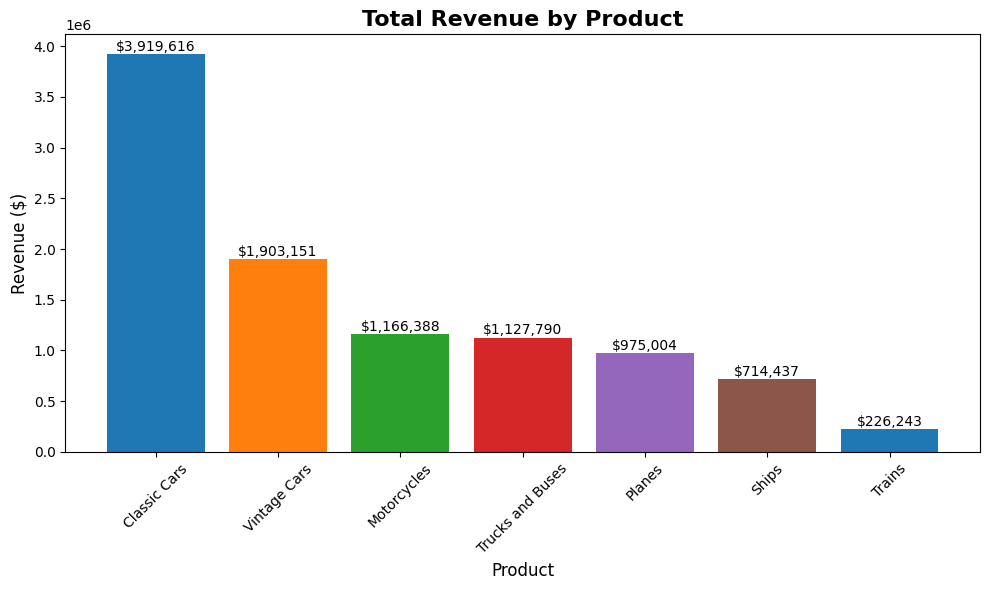

Revenue by Product:
Classic Cars: $3,919,615.66
Vintage Cars: $1,903,150.84
Motorcycles: $1,166,388.34
Trucks and Buses: $1,127,789.84
Planes: $975,003.57
Ships: $714,437.13
Trains: $226,243.47


In [19]:
# Create a bar chart of revenue by product line
product_revenue = df.groupby('PRODUCTLINE')['SALES'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
bars = plt.bar(product_revenue.index, product_revenue.values, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b'])
plt.title('Total Revenue by Product', fontsize=16, fontweight='bold')
plt.xlabel('Product', fontsize=12)
plt.ylabel('Revenue ($)', fontsize=12)
plt.xticks(rotation=45)

# Add value labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 1000,
             f'${height:,.0f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

# Print the actual numbers
print("Revenue by Product:")
for product, revenue in product_revenue.items():
    print(f"{product}: ${revenue:,.2f}")

In [ ]:
# Create a pie chart of market share by country
region_revenue = df.groupby('COUNTRY')['SALES'].sum().sort_values(ascending=True).tail(10)

plt.figure(figsize=(8, 8))
colors = ['#ff9999', '#66b3ff', '#99ff99', '#ffcc99', '#c2c2f0', '#ffb3e6', '#c4e17f', '#76f7b2', '#f7b76f', '#a6a6a6']
wedges, texts, autotexts = plt.pie(region_revenue.values, labels=region_revenue.index, 
                                   autopct='%1.0f%%', colors=colors, startangle=90)
plt.title('Market Share by Region', fontsize=16, fontweight='bold')

# Make percentage text more readable
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(12)

plt.show()

print("\nRegional market share:")
total_revenue = region_revenue.sum()
for region, revenue in region_revenue.items():
    percentage = (revenue / total_revenue) * 100
    print(f"{region}: ${revenue:,.2f} ({percentage:.1f}%)")

---
## Exercise: Customer Analysis Challenge

Now it's your turn! Let's create a customer dataset and perform some analysis.

In [20]:
# Create customer dataset for the exercise
def create_customer_data():
    """Generate customer satisfaction survey data."""
    random.seed(42)
    
    age_groups = ['18-25', '26-35', '36-45', '46-55', '55+']
    cities = ['New York', 'Los Angeles', 'Chicago', 'Houston', 'Phoenix']
    
    data = []
    for i in range(200):
        data.append({
            'Customer_ID': f'CUST_{i+1:04d}',
            'Age_Group': random.choice(age_groups),
            'City': random.choice(cities),
            'Satisfaction_Score': random.randint(1, 10),
            'Monthly_Spending': random.randint(50, 500),
            'Years_Customer': random.randint(1, 10)
        })
    
    return pd.DataFrame(data)

# Create the customer dataset
customers = create_customer_data()
customers.to_csv('customer_data.csv', index=False)
print("Customer dataset created!")
customers.head()

Customer dataset created!


,Customer_ID,Age_Group,City,Satisfaction_Score,Monthly_Spending,Years_Customer
0,CUST_0001,18-25,New York,5,175,4
1,CUST_0002,26-35,New York,9,94,10
2,CUST_0003,46-55,New York,1,97,4
3,CUST_0004,26-35,Phoenix,10,63,9
4,CUST_0005,26-35,Phoenix,7,162,8


### Your Task:
Complete the following analysis using the customer dataset. Fill in the missing code to answer each question.

Dataset shape: (200, 6)

First 3 rows:
  Customer_ID Age_Group      City  Satisfaction_Score  Monthly_Spending  \
0   CUST_0001     18-25  New York                   5               175   
1   CUST_0002     26-35  New York                   9                94   
2   CUST_0003     46-55  New York                   1                97   

   Years_Customer  
0               4  
1              10  
2               4  
Average satisfaction score: 5.84
Average spending by age group:
Age_Group
36-45    299.61
18-25    286.20
55+      281.32
26-35    277.04
46-55    260.52
Name: Monthly_Spending, dtype: float64

Number of high-value customers (>$300/month): 86


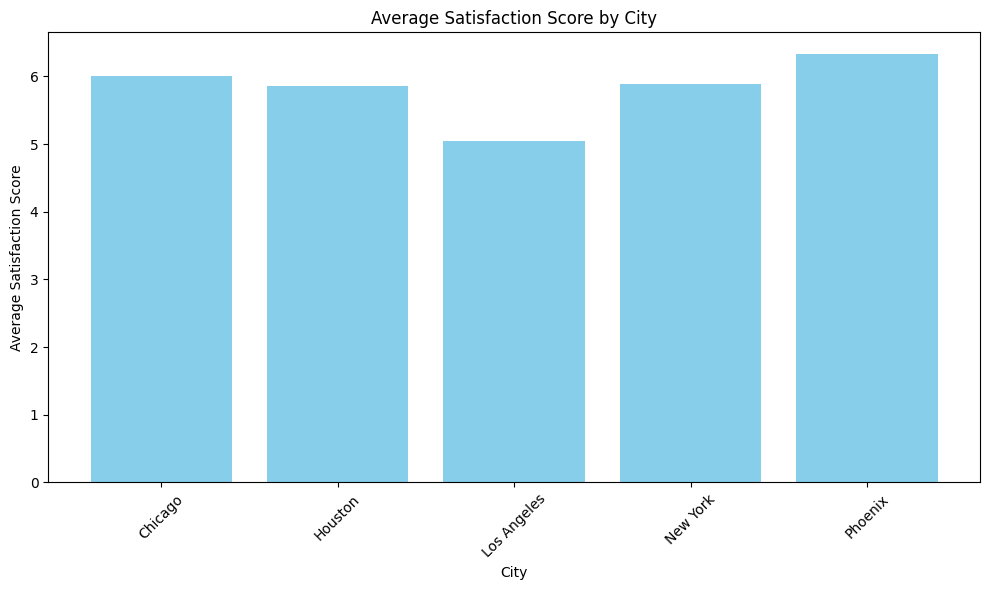

In [21]:
# Exercise: Customer Analysis

# 1. Load the customer data
# Load the customer_data.csv file into a DataFrame called 'customers'
customers = pd.read_csv('customer_data.csv')  # loaded from file

# 2. Basic exploration
print(f"Dataset shape: {customers.shape}")
print("\nFirst 3 rows:")
print(customers.head(3))

# 3. Find the average satisfaction score
avg_satisfaction = customers['Satisfaction_Score'].mean()
print(f"Average satisfaction score: {avg_satisfaction:.2f}")

# 4. Which age group spends the most money on average?
age_spending = customers.groupby('Age_Group')['Monthly_Spending'].mean().sort_values(ascending=False)
print("Average spending by age group:")
print(age_spending.round(2))

# 5. Find high-value customers
high_spenders = customers[customers['Monthly_Spending'] > 300]
print(f"\nNumber of high-value customers (>$300/month): {len(high_spenders)}")

# 6. Find the average satisfaction for each city
city_satisfaction = customers.groupby('City')['Satisfaction_Score'].mean()

# Plotting code (fill in the data)
plt.figure(figsize=(10, 6))
if city_satisfaction is not None and len(city_satisfaction):
    plt.bar(city_satisfaction.index, city_satisfaction.values, color='skyblue')
plt.title('Average Satisfaction Score by City')
plt.xlabel('City')
plt.ylabel('Average Satisfaction Score')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Solution (Try the exercise first!)

Dataset shape: (200, 6)

First 3 rows:
  Customer_ID Age_Group      City  Satisfaction_Score  Monthly_Spending  \
0   CUST_0001     18-25  New York                   5               175   
1   CUST_0002     26-35  New York                   9                94   
2   CUST_0003     46-55  New York                   1                97   

   Years_Customer  
0               4  
1              10  
2               4  

Average satisfaction score: 5.84

Average spending by age group:
Age_Group
36-45    299.61
18-25    286.20
55+      281.32
26-35    277.04
46-55    260.52
Name: Monthly_Spending, dtype: float64

Number of high-value customers (>$300/month): 86
Percentage of customers: 43.0%


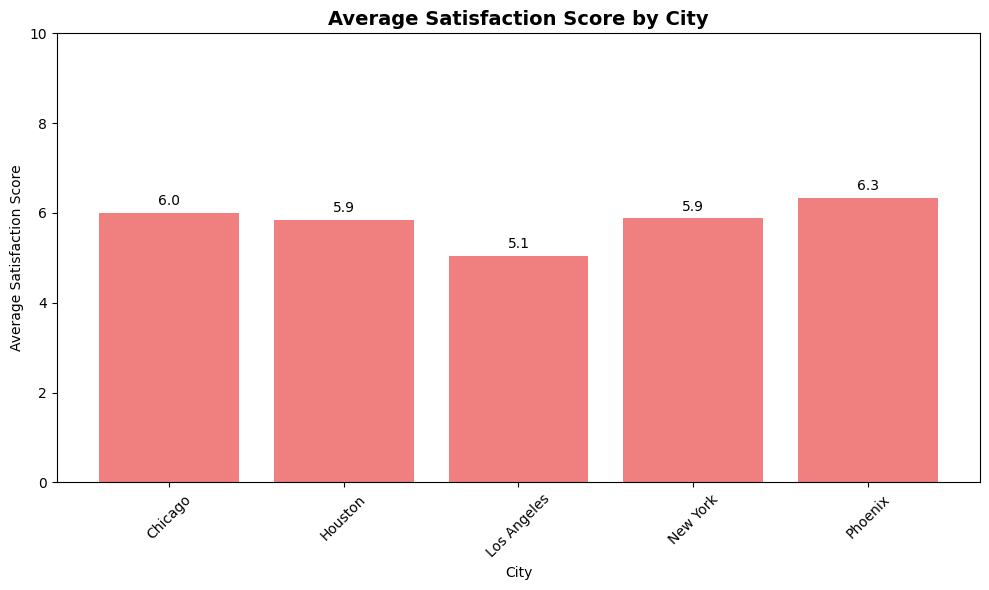


Satisfaction scores by city:
Chicago: 6.00/10
Houston: 5.85/10
Los Angeles: 5.05/10
New York: 5.88/10
Phoenix: 6.33/10


In [22]:
# Solution to Customer Analysis Exercise

# 1. Load the customer data
customers = pd.read_csv('customer_data.csv')

# 2. Basic exploration
print(f"Dataset shape: {customers.shape}")
print("\nFirst 3 rows:")
print(customers.head(3))

# 3. Average satisfaction score
avg_satisfaction = customers['Satisfaction_Score'].mean()
print(f"\nAverage satisfaction score: {avg_satisfaction:.2f}")

# 4. Spending by age group
age_spending = customers.groupby('Age_Group')['Monthly_Spending'].mean().sort_values(ascending=False)
print("\nAverage spending by age group:")
print(age_spending.round(2))

# 5. High-value customers
high_spenders = customers[customers['Monthly_Spending'] > 300]
print(f"\nNumber of high-value customers (>$300/month): {len(high_spenders)}")
print(f"Percentage of customers: {len(high_spenders)/len(customers)*100:.1f}%")

# 6. Visualization
city_satisfaction = customers.groupby('City')['Satisfaction_Score'].mean()

plt.figure(figsize=(10, 6))
bars = plt.bar(city_satisfaction.index, city_satisfaction.values, color='lightcoral')
plt.title('Average Satisfaction Score by City', fontsize=14, fontweight='bold')
plt.xlabel('City')
plt.ylabel('Average Satisfaction Score')
plt.ylim(0, 10)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.1,
             f'{height:.1f}', ha='center', va='bottom')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("\nSatisfaction scores by city:")
for city, score in city_satisfaction.items():
    print(f"{city}: {score:.2f}/10")

## What You've Accomplished

Congratulations! You've learned the fundamentals of data analysis with pandas:

- **Loading data** from CSV files into DataFrames
- **Exploring data** with basic statistics and summaries
- **Filtering and querying** data to find specific information
- **Grouping and aggregating** data to answer business questions
- **Creating visualizations** to communicate insights

These skills form the foundation of data science and are used daily by analysts, researchers, and data scientists worldwide.

## Next Steps

Continue building your data skills by:
- Finding an interesting dataset related to your hobbies on [Kaggle](https://www.kaggle.com/datasets).
- Learning advanced pandas operations (merging, pivoting, time series)
- Exploring other visualization libraries ([seaborn](https://seaborn.pydata.org/), [plotly](https://plotly.com/python/) - which can make ✨ interactive 3D graphs ✨)
- Moving into machine learning with scikit-learn

Remember: the best way to learn pandas is by analyzing data that interests you!